In [2]:
pip install opencv-python scikit-learn pandas numpy matplotlib jupyter

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached pandas-3.0.1-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
CSV_PATH = "chinese_mnist.csv"
IMG_DIR = "data/data"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (15000, 5)


,suite_id,sample_id,code,value,character
0,1,1,10,9,九
1,1,10,10,9,九
2,1,2,10,9,九
3,1,3,10,9,九
4,1,4,10,9,九


In [9]:
print("Total images:", len(df))

Total images: 15000


In [10]:
print("Unique classes:", df["code"].nunique())
print("Classes:", sorted(df["code"].unique()))

Unique classes: 15
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


In [11]:
df["code"].value_counts()

code
10    1000
11    1000
12    1000
13    1000
14    1000
15    1000
1     1000
2     1000
3     1000
4     1000
5     1000
6     1000
7     1000
8     1000
9     1000
Name: count, dtype: int64

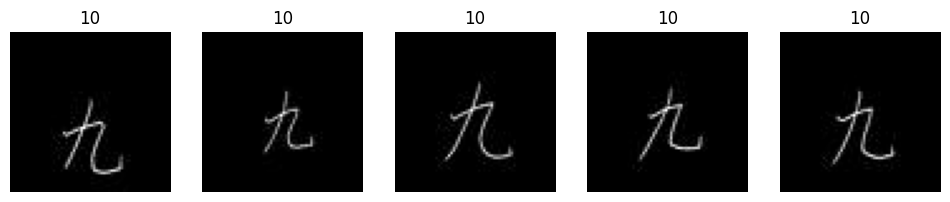

In [12]:
fig, axes = plt.subplots(1,5, figsize=(12,4))

for i, ax in enumerate(axes):
    
    row = df.iloc[i]
    
    filename = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
    path = os.path.join(IMG_DIR, filename)
    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    ax.imshow(img, cmap="gray")
    ax.set_title(row["code"])
    ax.axis("off")

plt.show()

In [13]:
train_df, temp_df = train_test_split(
    df,
    train_size=5000,
    stratify=df["code"],
    random_state=42
)

test_df, _ = train_test_split(
    temp_df,
    train_size=1000,
    stratify=temp_df["code"],
    random_state=42
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 5000
Testing samples: 1000


In [14]:
print(train_df["code"].value_counts())
print(test_df["code"].value_counts())

code
12    334
6     334
1     334
14    334
10    334
5     333
9     333
13    333
3     333
7     333
8     333
11    333
15    333
4     333
2     333
Name: count, dtype: int64
code
11    67
15    67
13    67
9     67
3     67
4     67
7     67
5     67
8     67
2     67
6     66
1     66
14    66
12    66
10    66
Name: count, dtype: int64


In [ ]:
def load_images(dataframe):
    
    images = []
    labels = []
    
    for _, row in dataframe.iterrows():
        
        filename = f"input_{row['suite_id']}_{row['sample_id']}_{row['code']}.jpg"
        path = os.path.join(IMG_DIR, filename)
        
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        
        img = img.reshape(-1)   
        
        images.append(img)
        labels.append(row["code"])
    
    return np.array(images), np.array(labels)

In [16]:
X_train, y_train = load_images(train_df)
X_test, y_test = load_images(test_df)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5000, 4096)
Testing shape: (1000, 4096)


In [17]:
knn = KNeighborsClassifier(n_neighbors=3)

dt = DecisionTreeClassifier()

sgd = SGDClassifier(max_iter=250)

In [18]:
knn.fit(X_train, y_train)

dt.fit(X_train, y_train)

sgd.fit(X_train, y_train)

c:\Users\Kapil Vinayak\OneDrive - UNSW\Desktop\lab3\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",250
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [19]:
knn_pred = knn.predict(X_test)

dt_pred = dt.predict(X_test)

sgd_pred = sgd.predict(X_test)

In [20]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

print("\nClassification Report:")
print(classification_report(y_test, knn_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.332

Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.59      0.65        66
           2       0.15      0.97      0.25        67
           3       0.27      0.43      0.33        67
           4       0.29      0.21      0.24        67
           5       0.39      0.13      0.20        67
           6       0.27      0.09      0.14        66
           7       0.21      0.13      0.17        67
           8       0.41      0.18      0.25        67
           9       0.88      0.79      0.83        67
          10       0.71      0.26      0.38        66
          11       0.44      0.45      0.44        67
          12       0.85      0.17      0.28        66
          13       0.71      0.22      0.34        67
          14       0.43      0.18      0.26        66
          15       1.00      0.16      0.28        67

    accuracy                           0.33      1000
   macro avg       0.52      0.33   

In [21]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.276

Classification Report:
              precision    recall  f1-score   support

           1       0.40      0.26      0.31        66
           2       0.62      0.61      0.62        67
           3       0.26      0.34      0.29        67
           4       0.15      0.15      0.15        67
           5       0.25      0.22      0.24        67
           6       0.18      0.20      0.19        66
           7       0.19      0.21      0.20        67
           8       0.21      0.21      0.21        67
           9       0.38      0.42      0.40        67
          10       0.23      0.26      0.24        66
          11       0.38      0.43      0.40        67
          12       0.22      0.21      0.22        66
          13       0.32      0.33      0.33        67
          14       0.13      0.11      0.12        66
          15       0.23      0.18      0.20        67

    accuracy                           0.28      1000
   macro avg       0.28   

In [22]:
print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))

print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, sgd_pred))

SGD Accuracy: 0.262

Classification Report:
              precision    recall  f1-score   support

           1       0.40      0.39      0.40        66
           2       0.43      0.34      0.38        67
           3       0.22      0.24      0.23        67
           4       0.41      0.27      0.32        67
           5       0.30      0.31      0.31        67
           6       0.21      0.32      0.25        66
           7       0.25      0.21      0.23        67
           8       0.22      0.28      0.25        67
           9       0.24      0.18      0.21        67
          10       0.15      0.17      0.16        66
          11       0.44      0.40      0.42        67
          12       0.14      0.18      0.16        66
          13       0.27      0.22      0.25        67
          14       0.17      0.17      0.17        66
          15       0.26      0.24      0.25        67

    accuracy                           0.26      1000
   macro avg       0.27      0.26   

In [23]:
train_df2, temp_df2 = train_test_split(
    df,
    train_size=10000,
    stratify=df["code"],
    random_state=42
)

test_df2, _ = train_test_split(
    temp_df2,
    train_size=1000,
    stratify=temp_df2["code"],
    random_state=42
)

In [24]:
X_train2, y_train2 = load_images(train_df2)
X_test2, y_test2 = load_images(test_df2)

In [25]:
knn.fit(X_train2, y_train2)
dt.fit(X_train2, y_train2)
sgd.fit(X_train2, y_train2)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",250
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [26]:
knn_pred2 = knn.predict(X_test2)
dt_pred2 = dt.predict(X_test2)
sgd_pred2 = sgd.predict(X_test2)

In [27]:
print("KNN Accuracy (10000 training):", accuracy_score(y_test2, knn_pred2))

print("Decision Tree Accuracy (10000 training):", accuracy_score(y_test2, dt_pred2))

print("SGD Accuracy (10000 training):", accuracy_score(y_test2, sgd_pred2))

KNN Accuracy (10000 training): 0.416
Decision Tree Accuracy (10000 training): 0.318
SGD Accuracy (10000 training): 0.312
